# ML_hepatitis_bc: Hepatitis B/C Prediction

**Purpose:** Build and evaluate machine learning models to predict `hepatitis_bc` (binary 0/1) from NHANES survey and lab features.

**Target:** `hepatitis_bc` — 1 = Hepatitis B or C present, 0 = not present.

**Challenge:** Severe class imbalance — only 192 positives out of 7,437 total (2.6%). Approaches used:
- `class_weight='balanced'` in all LR and RF models
- `scale_pos_weight ≈ 37.7` in XGBoost
- Screening threshold THR=0.15 (lower than 0.3 used for common conditions)

**Rule of thumb:** Max ~15–19 predictors given 192 events. Final model kept lean.

**Approach:** Logistic Regression (L1/L2), Random Forest, XGBoost, and soft-vote ensemble. Threshold set at 0.15 for screening (prioritize recall for rare disease).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings, joblib, json, os
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score, precision_score,
                              accuracy_score, f1_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils import resample
from xgboost import XGBClassifier
from scipy.stats import mannwhitneyu
warnings.filterwarnings('ignore')
SEED = 42
THR  = 0.15
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


## Section 1: Data Loading & Feature Map

In [2]:
df_raw = pd.read_csv('../data/processed/nhanes_merged_adults_final.csv', low_memory=False)

FEATURE_MAP = {
    # LAB
    'alt':            'LBXSATSI_alanine_aminotransferase_alt_u_l',
    'ast':            'LBXSASSI_aspartate_aminotransferase_ast_u_l',
    'ggt':            'LBXSGTSI_gamma_glutamyl_transferase_ggt_iu_l',
    'bilirubin':      'LBXSTB_total_bilirubin_mg_dl',
    'albumin':        'LBXSAL_albumin_refrigerated_serum_g_dl',
    'total_protein':  'LBXSTP_total_protein_g_dl',
    'alp':            'LBXSAPSI_alkaline_phosphatase_alp_iu_l',
    'platelet':       'LBXPLTSI_platelet_count_1000_cells_ul',
    'wbc':            'LBXWBCSI_white_blood_cell_count_1000_cells_ul',
    'hemoglobin':     'LBXHGB_hemoglobin_g_dl',
    'ferritin':       'LBXFER_ferritin_ng_ml',
    'creatinine':     'LBXSCR_creatinine_refrigerated_serum_mg_dl',
    'cholesterol':    'LBXTC_total_cholesterol_mg_dl',
    'triglycerides':  'LBXTR_triglyceride_mg_dl',
    'hdl':            'LBDHDD_direct_hdl_cholesterol_mg_dl',
    'glucose':        'LBXSGL_glucose_refrigerated_serum_mg_dl',
    'bun':            'LBXSBU_blood_urea_nitrogen_mg_dl',
    'bmi':            'bmi',
    'waist_cm':       'waist_cm',
    # BP/pulse (will be averaged below)
    'sbp_1': 'sbp_1', 'sbp_2': 'sbp_2', 'sbp_3': 'sbp_3',
    'dbp_1': 'dbp_1', 'dbp_2': 'dbp_2', 'dbp_3': 'dbp_3',
    'pulse_1': 'pulse_1', 'pulse_2': 'pulse_2', 'pulse_3': 'pulse_3',
    # QUEST
    'age_years':           'age_years',
    'gender':              'gender',
    'ethnicity':           'ethnicity',
    'country_of_birth':    'country_of_birth',
    'education':           'education',
    'income_poverty_ratio':'income_poverty_ratio',
    'avg_drinks_per_day':  'alq130___avg_#_alcoholic_drinks/day___past_12_mos',
    'ever_heavy_drinker':  'alq151___ever_have_4/5_or_more_drinks_every_day?',
    'blood_transfusion':   'mcq092___ever_receive_blood_transfusion',
    'smoked_100_cigs':     'smq020___smoked_at_least_100_cigarettes_in_life',
    'diabetes':            'diq010___doctor_told_you_have_diabetes',
    'liver_condition':     'mcq160l___ever_told_you_had_any_liver_condition',
    'general_health':      'huq010___general_health_condition',
    'hospitalized_lastyear': 'huq071___overnight_hospital_patient_in_last_year',
    # TARGET
    'hepatitis_bc':        'hepatitis_bc',
}

_valid = {k: v for k, v in FEATURE_MAP.items() if v in df_raw.columns}
df = df_raw[list(_valid.values())].copy()
df.columns = list(_valid.keys())

# Average repeated BP/pulse readings
for pfx in ['sbp', 'dbp', 'pulse']:
    cs = [c for c in df.columns if c.startswith(f'{pfx}_')]
    if cs:
        df[f'{pfx}_mean'] = df[cs].mean(axis=1)
        df.drop(columns=cs, inplace=True)

TARGET = 'hepatitis_bc'
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

# Encode string/categorical columns
for col in df.select_dtypes(include=['object', 'category']).columns:
    if col != TARGET:
        codes = pd.Categorical(df[col]).codes
        df[col] = pd.Series(codes.astype(float), index=df.index).replace(-1, np.nan)

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Features: {df.shape[1]-1}')
print(f'Target positive rate: {df[TARGET].mean()*100:.1f}%')
print(f'Positives: {df[TARGET].sum():,}  Negatives: {(df[TARGET]==0).sum():,}')
df.head(3)

Dataset: 7,437 rows x 37 columns
Features: 36
Target positive rate: 2.6%
Positives: 192  Negatives: 7,245


,alt,ast,ggt,bilirubin,albumin,total_protein,alp,platelet,wbc,hemoglobin,...,blood_transfusion,smoked_100_cigs,diabetes,liver_condition,general_health,hospitalized_lastyear,hepatitis_bc,sbp_mean,dbp_mean,pulse_mean
0,15.0,14.0,8.0,0.5,3.8,6.8,74.0,314.0,7.8,12.3,...,9.0,2.0,2.0,2.0,3.0,2.0,0,99.0,54.333333,66.666667
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,2.0,2.0,1.0,2.0,0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,2.0,NaN,3.0,2.0,0,NaN,NaN,NaN


## Section 2: Exploratory Data Analysis

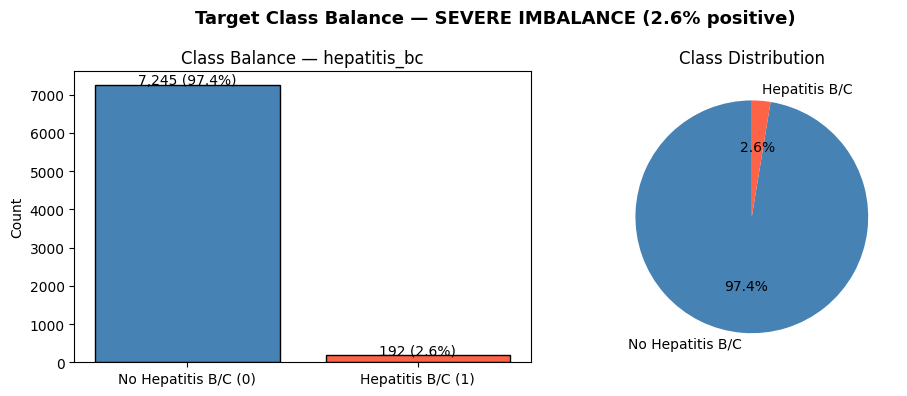

Class 0: 7,245 (97.4%)
Class 1: 192 (2.6%)
Imbalance ratio: 37.7:1
scale_pos_weight for XGBoost: 37.73


In [3]:
# Class balance
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df[TARGET].value_counts().sort_index()
ax[0].bar(['No Hepatitis B/C (0)', 'Hepatitis B/C (1)'], counts.values,
          color=['steelblue', 'tomato'], edgecolor='black')
ax[0].set_title('Class Balance — hepatitis_bc')
ax[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

ax[1].pie(counts.values, labels=['No Hepatitis B/C', 'Hepatitis B/C'],
          autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
ax[1].set_title('Class Distribution')
plt.suptitle('Target Class Balance — SEVERE IMBALANCE (2.6% positive)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Class 0: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Class 1: {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1')
print(f'scale_pos_weight for XGBoost: {counts[0]/counts[1]:.2f}')

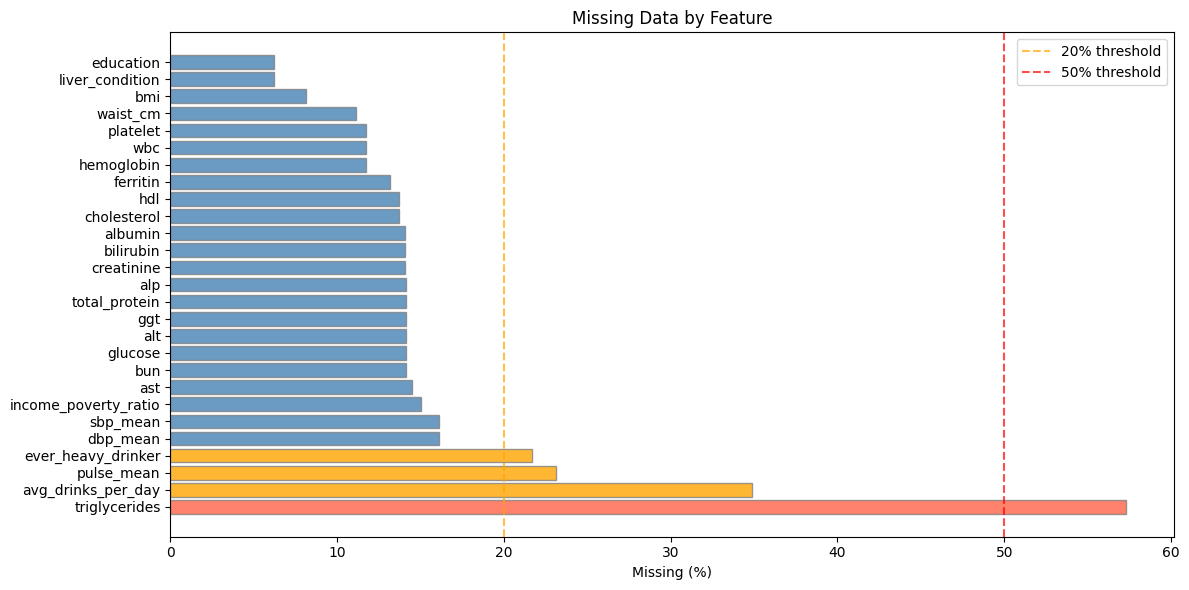

Features with any missing: 27/36
Features >50% missing: 1
Features >20% missing: 4


In [4]:
# Missing data bar chart
feat_cols = [c for c in df.columns if c != TARGET]
miss_pct = df[feat_cols].isnull().mean().sort_values(ascending=False)
miss_pct_nonzero = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['tomato' if v > 0.5 else 'orange' if v > 0.2 else 'steelblue' for v in miss_pct_nonzero.values]
ax.barh(miss_pct_nonzero.index, miss_pct_nonzero.values * 100, color=colors, edgecolor='gray', alpha=0.8)
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Features with any missing: {len(miss_pct_nonzero)}/{len(feat_cols)}')
print(f'Features >50% missing: {(miss_pct > 0.5).sum()}')
print(f'Features >20% missing: {(miss_pct > 0.2).sum()}')

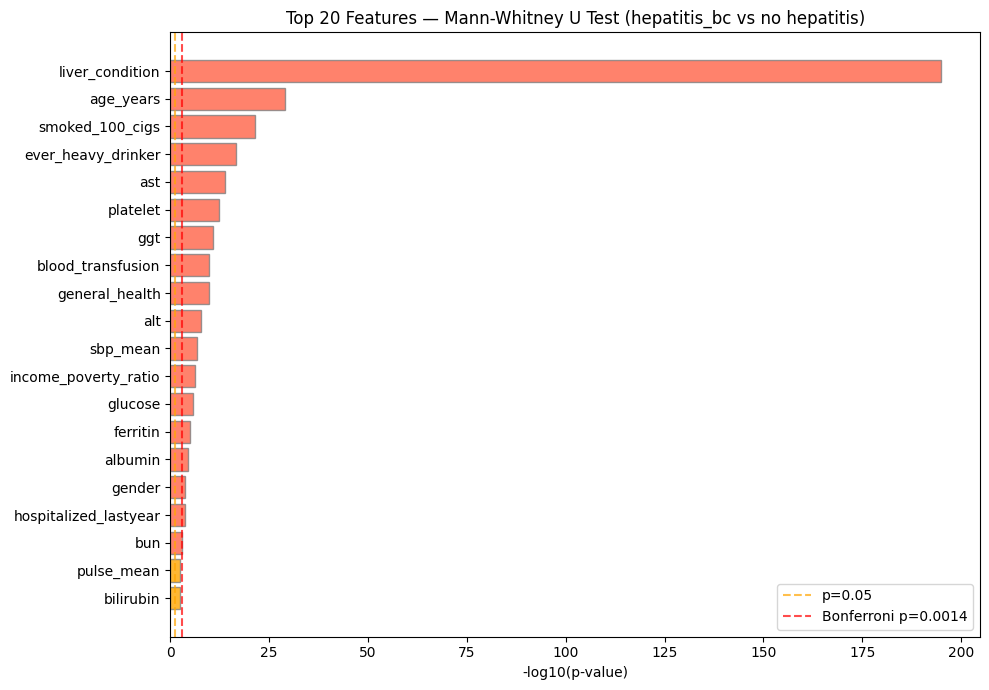

Features with p < 0.05: 30
Features with Bonferroni-corrected p < 0.05: 18

Top 10 most significant features:
liver_condition       8.961129e-196
age_years              1.107209e-29
smoked_100_cigs        3.240825e-22
ever_heavy_drinker     2.468708e-17
ast                    1.622787e-14
platelet               5.007160e-13
ggt                    1.388204e-11
blood_transfusion      1.903744e-10
general_health         2.182792e-10
alt                    2.300035e-08


In [5]:
# Feature distributions by target (Mann-Whitney U)
numeric_feats = [c for c in feat_cols if df[c].dtype in [np.float64, np.int64, float, int]]
pvals = {}
for col in numeric_feats:
    g0 = df.loc[df[TARGET]==0, col].dropna()
    g1 = df.loc[df[TARGET]==1, col].dropna()
    if len(g0) > 10 and len(g1) > 10:
        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        pvals[col] = p

pval_series = pd.Series(pvals).sort_values()
top20 = pval_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
log10p = -np.log10(top20.values + 1e-300)
bonferroni = 0.05 / len(pvals)
colors = ['tomato' if p < bonferroni else 'orange' if p < 0.05 else 'steelblue' for p in top20.values]
ax.barh(top20.index[::-1], log10p[::-1], color=colors[::-1], edgecolor='gray', alpha=0.8)
ax.axvline(-np.log10(0.05), color='orange', linestyle='--', alpha=0.7, label='p=0.05')
ax.axvline(-np.log10(bonferroni), color='red', linestyle='--', alpha=0.7,
           label=f'Bonferroni p={bonferroni:.4f}')
ax.set_xlabel('-log10(p-value)')
ax.set_title('Top 20 Features — Mann-Whitney U Test (hepatitis_bc vs no hepatitis)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Features with p < 0.05: {(pval_series < 0.05).sum()}')
print(f'Features with Bonferroni-corrected p < 0.05: {(pval_series < bonferroni).sum()}')
print('\nTop 10 most significant features:')
print(pval_series.head(10).to_string())

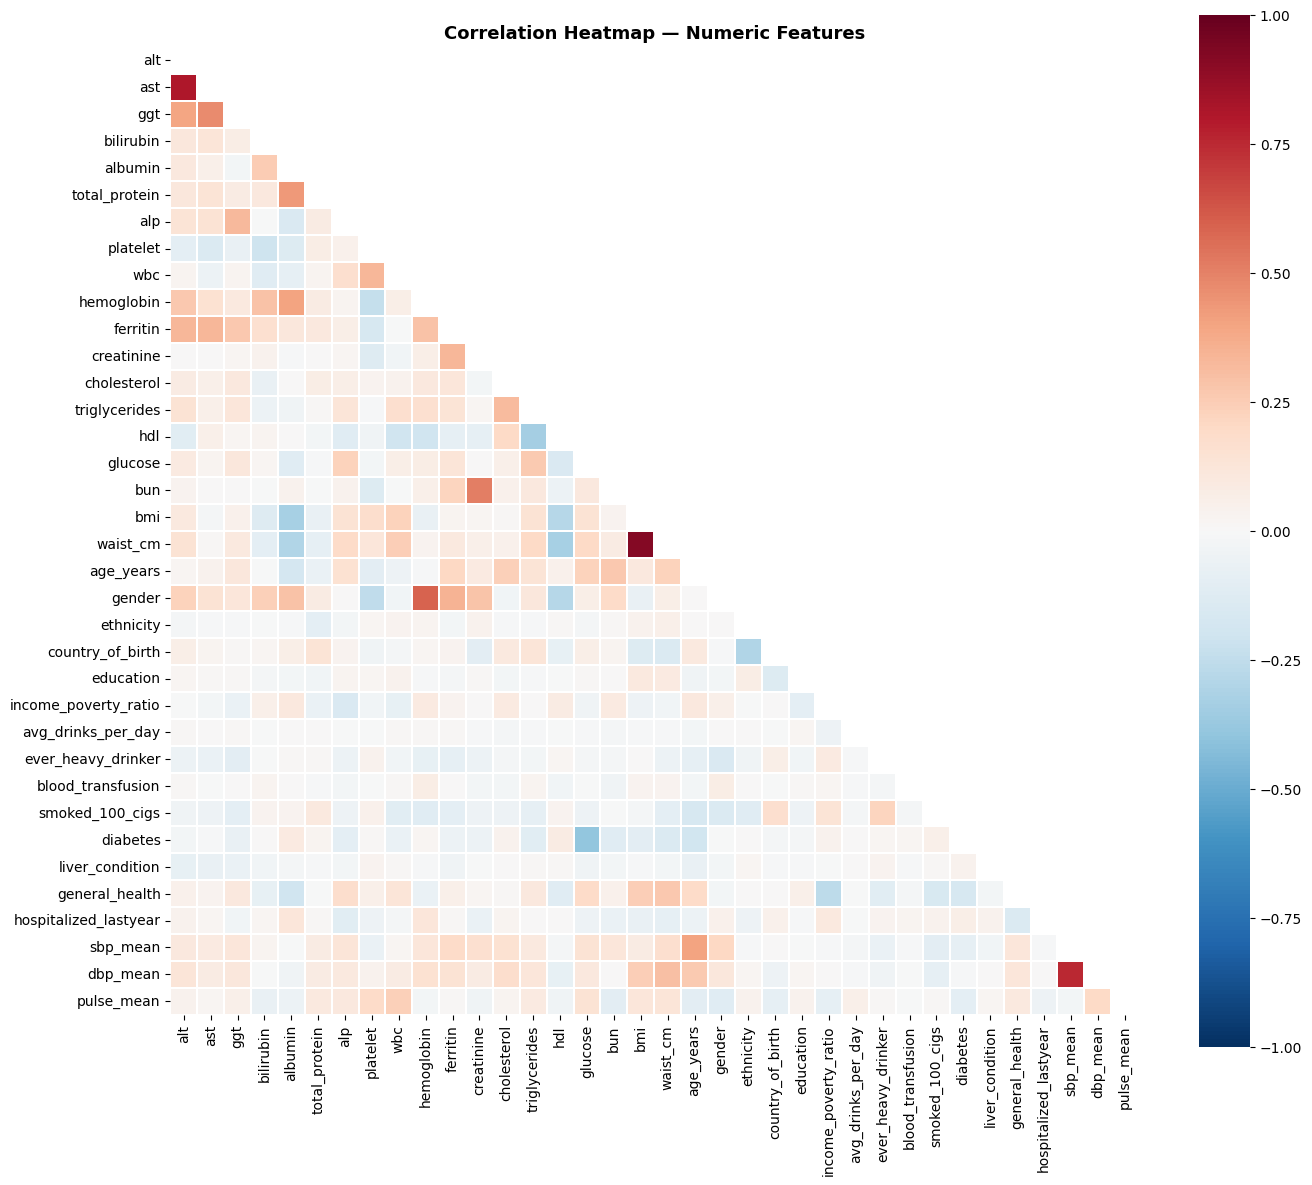

Highly correlated pairs (|r|>0.7): 3
  bmi <-> waist_cm: 0.921
  alt <-> ast: 0.809
  sbp_mean <-> dbp_mean: 0.753


In [6]:
# Correlation heatmap
corr_feats = [c for c in numeric_feats if df[c].isnull().mean() < 0.7]
corr_matrix = df[corr_feats].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(v, 3)))
if high_corr:
    print(f'Highly correlated pairs (|r|>0.7): {len(high_corr)}')
    for a, b, v in sorted(high_corr, key=lambda x: -abs(x[2]))[:10]:
        print(f'  {a} <-> {b}: {v}')

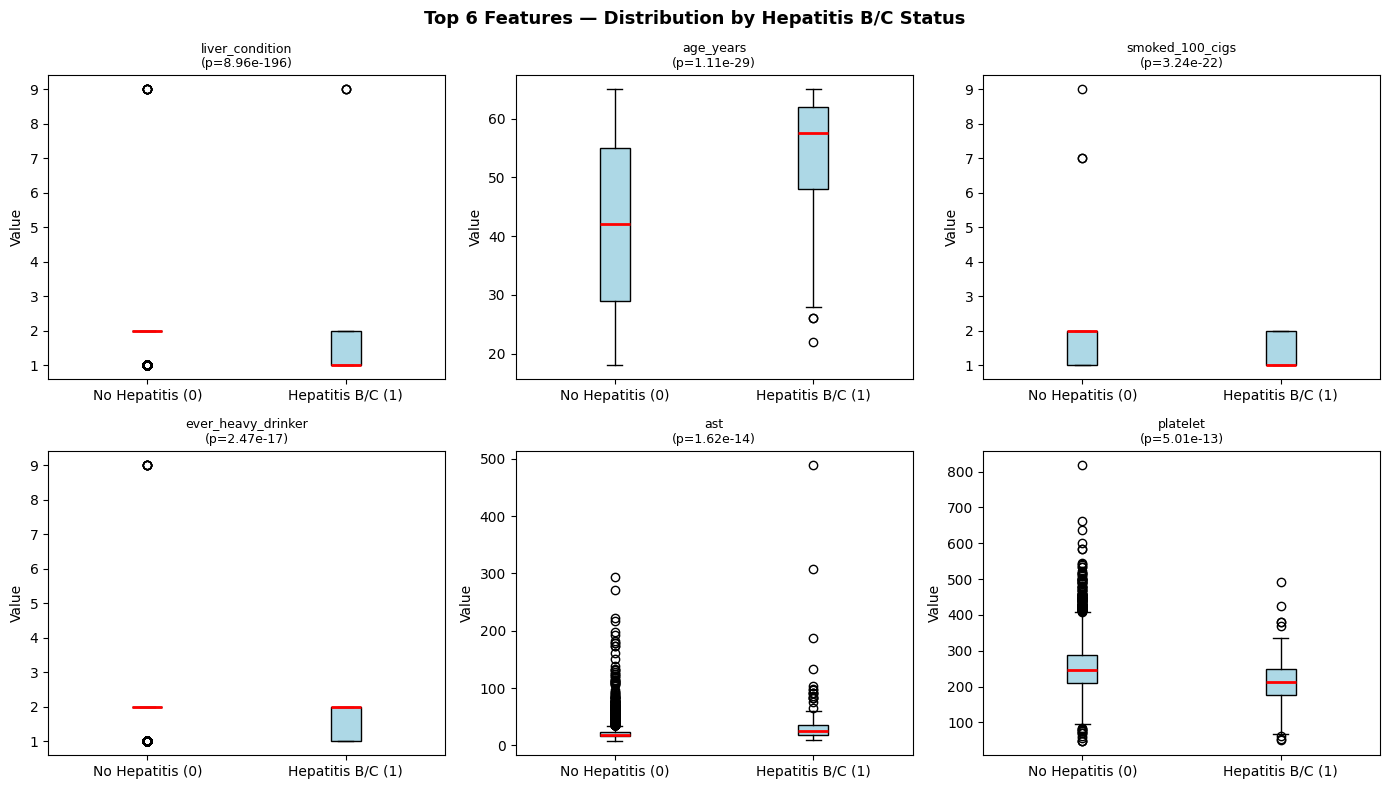

In [7]:
# Box plots comparing top 6 features by target class
top6_feats = pval_series.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), top6_feats):
    data0 = df.loc[df[TARGET]==0, feat].dropna()
    data1 = df.loc[df[TARGET]==1, feat].dropna()
    ax.boxplot([data0, data1], labels=['No Hepatitis (0)', 'Hepatitis B/C (1)'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', lw=2))
    p = pval_series.get(feat, 1.0)
    ax.set_title(f'{feat}\n(p={p:.2e})', fontsize=9)
    ax.set_ylabel('Value')

plt.suptitle('Top 6 Features — Distribution by Hepatitis B/C Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3: Feature Groups

In [8]:
LAB_FEATURES = [c for c in [
    'alt', 'ast', 'ggt', 'bilirubin', 'albumin', 'total_protein', 'alp',
    'platelet', 'wbc', 'hemoglobin', 'ferritin', 'creatinine',
    'cholesterol', 'triglycerides', 'hdl', 'glucose', 'bun',
    'bmi', 'waist_cm', 'sbp_mean', 'dbp_mean', 'pulse_mean'
] if c in df.columns]

QUEST_FEATURES = [c for c in [
    'age_years', 'gender', 'ethnicity', 'country_of_birth', 'education',
    'income_poverty_ratio', 'avg_drinks_per_day', 'ever_heavy_drinker',
    'blood_transfusion', 'smoked_100_cigs', 'diabetes', 'liver_condition',
    'general_health', 'hospitalized_lastyear'
] if c in df.columns]

ALL_FEATURES = list(dict.fromkeys(LAB_FEATURES + QUEST_FEATURES))
print(f'LAB features: {len(LAB_FEATURES)}')
print(f'QUEST features: {len(QUEST_FEATURES)}')
print(f'ALL features: {len(ALL_FEATURES)}')
print('\nLAB:', LAB_FEATURES)
print('\nQUEST:', QUEST_FEATURES)

LAB features: 22
QUEST features: 14
ALL features: 36

LAB: ['alt', 'ast', 'ggt', 'bilirubin', 'albumin', 'total_protein', 'alp', 'platelet', 'wbc', 'hemoglobin', 'ferritin', 'creatinine', 'cholesterol', 'triglycerides', 'hdl', 'glucose', 'bun', 'bmi', 'waist_cm', 'sbp_mean', 'dbp_mean', 'pulse_mean']

QUEST: ['age_years', 'gender', 'ethnicity', 'country_of_birth', 'education', 'income_poverty_ratio', 'avg_drinks_per_day', 'ever_heavy_drinker', 'blood_transfusion', 'smoked_100_cigs', 'diabetes', 'liver_condition', 'general_health', 'hospitalized_lastyear']


## Section 4: Preprocessing

In [9]:
def add_missing_flags(df_feat):
    flags = {f'{c}_miss': df_feat[c].isnull().astype(int)
             for c in df_feat.columns if df_feat[c].isnull().any()}
    return pd.concat([df_feat, pd.DataFrame(flags, index=df_feat.index)], axis=1) if flags else df_feat

X_lab_full    = add_missing_flags(df[LAB_FEATURES])
X_quest_full  = add_missing_flags(df[QUEST_FEATURES])
X_all_full    = add_missing_flags(df[ALL_FEATURES])
y_full        = df[TARGET]

# Class counts for scale_pos_weight
n_neg = (y_full == 0).sum()
n_pos = (y_full == 1).sum()
SCALE_POS_WEIGHT = n_neg / n_pos
print(f'n_neg={n_neg}, n_pos={n_pos}, scale_pos_weight={SCALE_POS_WEIGHT:.2f}')

_idx = np.arange(len(df))
tr_idx, te_idx = train_test_split(_idx, test_size=0.2, stratify=y_full.values, random_state=SEED)
X_tr = X_all_full.iloc[tr_idx]; X_te = X_all_full.iloc[te_idx]
y_tr = y_full.iloc[tr_idx];     y_te = y_full.iloc[te_idx]
print(f'Train: {len(tr_idx):,} | Test: {len(te_idx):,}')
print(f'Train positive rate: {y_tr.mean()*100:.2f}% | Test: {y_te.mean()*100:.2f}%')
print(f'Train positives: {y_tr.sum()} | Test positives: {y_te.sum()}')

# Pipeline factories
def make_lr_l2(C=1.0):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', C=C, class_weight='balanced',
                                   max_iter=2000, random_state=SEED, solver='lbfgs'))
    ])

def make_lr_l1(C=1.0):
    # Use saga + l1_ratio=1 (ElasticNet with pure L1) to avoid deprecation in sklearn 1.8
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(penalty='elasticnet', C=C, l1_ratio=1.0,
                                   class_weight='balanced', max_iter=3000,
                                   random_state=SEED, solver='saga'))
    ])

def make_rf():
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        random_state=SEED, n_jobs=-1))
    ])

print(f'\nFeature matrix shapes:')
print(f'  X_all_full: {X_all_full.shape}')
print(f'  X_lab_full: {X_lab_full.shape}')
print(f'  X_quest_full: {X_quest_full.shape}')
print(f'\nScreening threshold: THR = {THR}')

n_neg=7245, n_pos=192, scale_pos_weight=37.73
Train: 5,949 | Test: 1,488
Train positive rate: 2.59% | Test: 2.55%
Train positives: 154 | Test positives: 38

Feature matrix shapes:
  X_all_full: (7437, 63)
  X_lab_full: (7437, 44)
  X_quest_full: (7437, 19)

Screening threshold: THR = 0.15


## Section 5: Baseline Models (LR L2 & LR L1)

In [10]:
def eval_model(model, X_te, y_te, thr=THR, name=''):
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= thr).astype(int)
    return {
        'name': name, 'prob': prob,
        'ROC-AUC':       round(roc_auc_score(y_te, prob), 4),
        'Avg Precision': round(average_precision_score(y_te, prob), 4),
        'Recall':        round(recall_score(y_te, pred, zero_division=0), 4),
        'Precision':     round(precision_score(y_te, pred, zero_division=0), 4),
        'Accuracy':      round(accuracy_score(y_te, pred), 4),
        'F1':            round(f1_score(y_te, pred, zero_division=0), 4),
    }

lr_l2 = make_lr_l2(C=1.0); lr_l2.fit(X_tr, y_tr)
lr_l1 = make_lr_l1(C=1.0); lr_l1.fit(X_tr, y_tr)

res_l2 = eval_model(lr_l2, X_te, y_te, THR, 'LR L2')
res_l1 = eval_model(lr_l1, X_te, y_te, THR, 'LR L1')
for r in [res_l2, res_l1]:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} Recall={r['Recall']} Prec={r['Precision']} F1={r['F1']}")

LR L2        ROC-AUC=0.7765 Recall=0.8947 Prec=0.0385 F1=0.0738
LR L1        ROC-AUC=0.7773 Recall=0.8947 Prec=0.0382 F1=0.0733


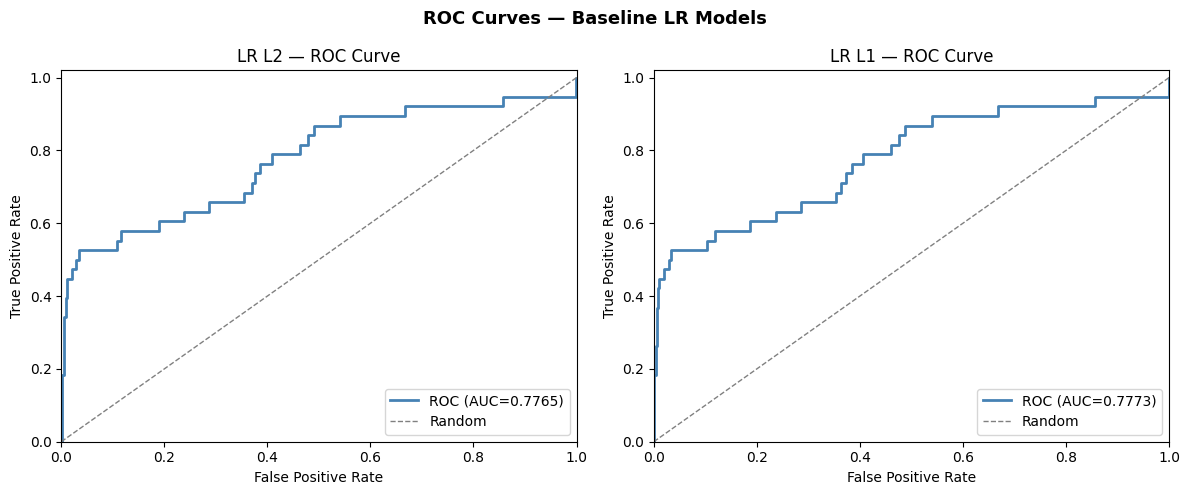

In [11]:
# ROC curves for LR L2 and LR L1 side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, model_name in zip(axes, [res_l2, res_l1], ['LR L2', 'LR L1']):
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'ROC (AUC={auc})')
    ax.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} — ROC Curve')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — Baseline LR Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

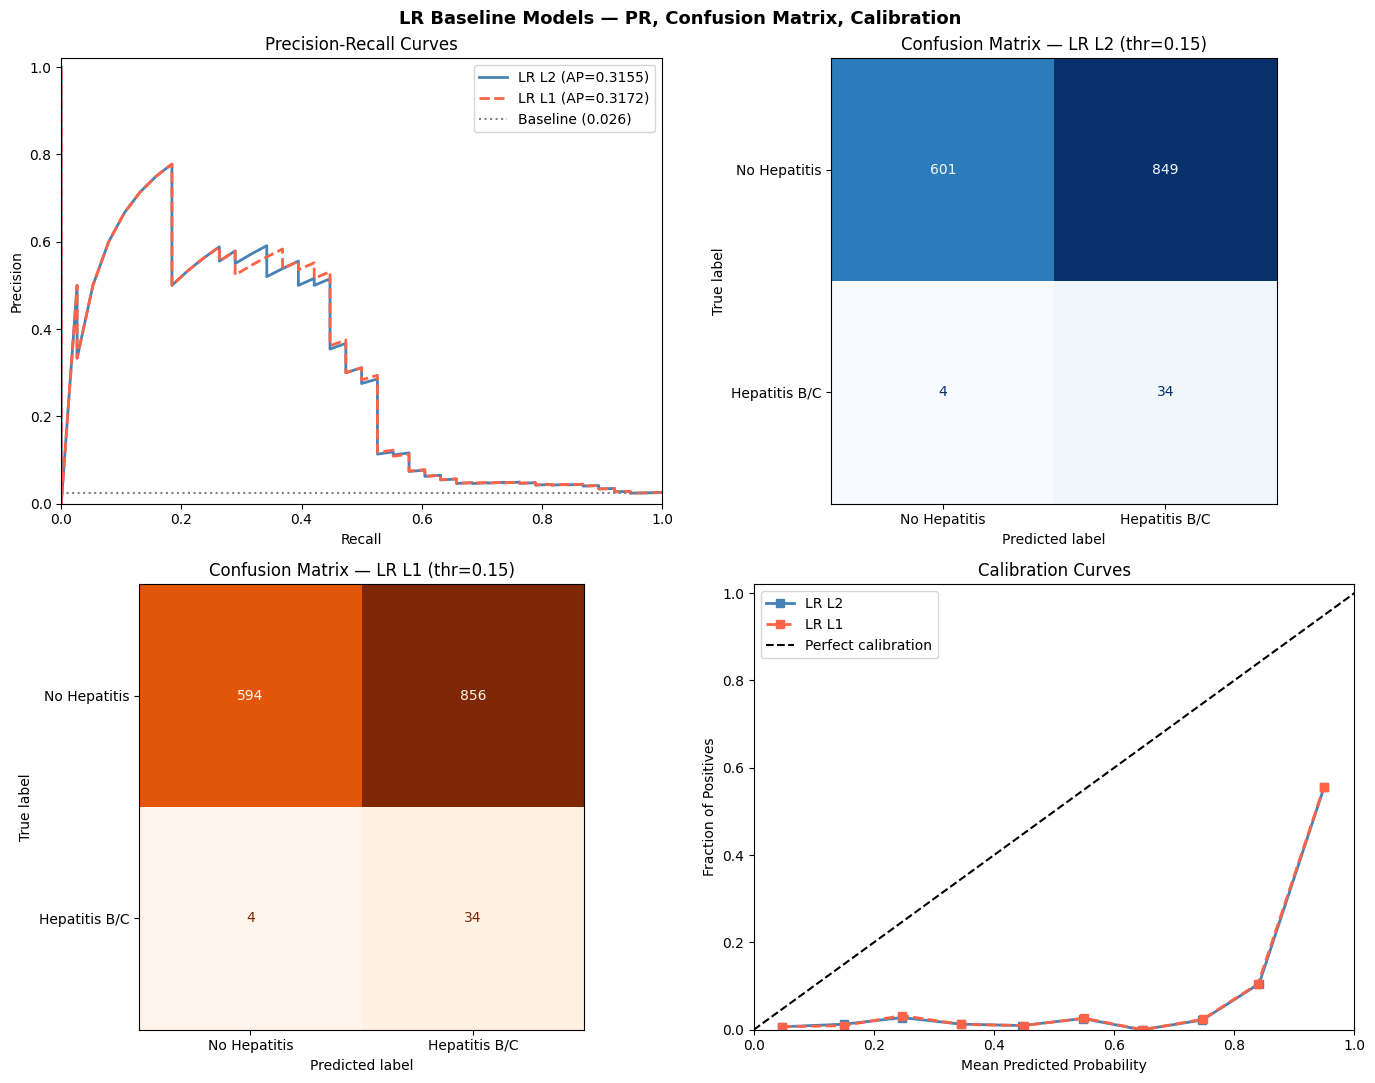

In [12]:
# PR curves, Confusion matrices, Calibration curves
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# PR curves
ax = axes[0, 0]
for res, col, ls in [(res_l2, 'steelblue', '-'), (res_l1, 'tomato', '--')]:
    prec, rec, _ = precision_recall_curve(y_te, res['prob'])
    ap = res['Avg Precision']
    ax.plot(rec, prec, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AP={ap})")
baseline_pr = y_te.mean()
ax.axhline(baseline_pr, color='gray', linestyle=':', lw=1.5, label=f'Baseline ({baseline_pr:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Confusion matrix LR L2
ax = axes[0, 1]
pred_l2 = (res_l2['prob'] >= THR).astype(int)
cm = confusion_matrix(y_te, pred_l2)
ConfusionMatrixDisplay(cm, display_labels=['No Hepatitis', 'Hepatitis B/C']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — LR L2 (thr={THR})')

# Confusion matrix LR L1
ax = axes[1, 0]
pred_l1 = (res_l1['prob'] >= THR).astype(int)
cm1 = confusion_matrix(y_te, pred_l1)
ConfusionMatrixDisplay(cm1, display_labels=['No Hepatitis', 'Hepatitis B/C']).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Confusion Matrix — LR L1 (thr={THR})')

# Calibration curves
ax = axes[1, 1]
for res, col, ls in [(res_l2, 'steelblue', '-'), (res_l1, 'tomato', '--')]:
    frac_pos, mean_pred = calibration_curve(y_te, res['prob'], n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=col, linestyle=ls, lw=2, label=res['name'])
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('LR Baseline Models — PR, Confusion Matrix, Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Optimal threshold for recall>=0.80: 0.210
  Recall=0.816, Precision=0.044, F1=0.084


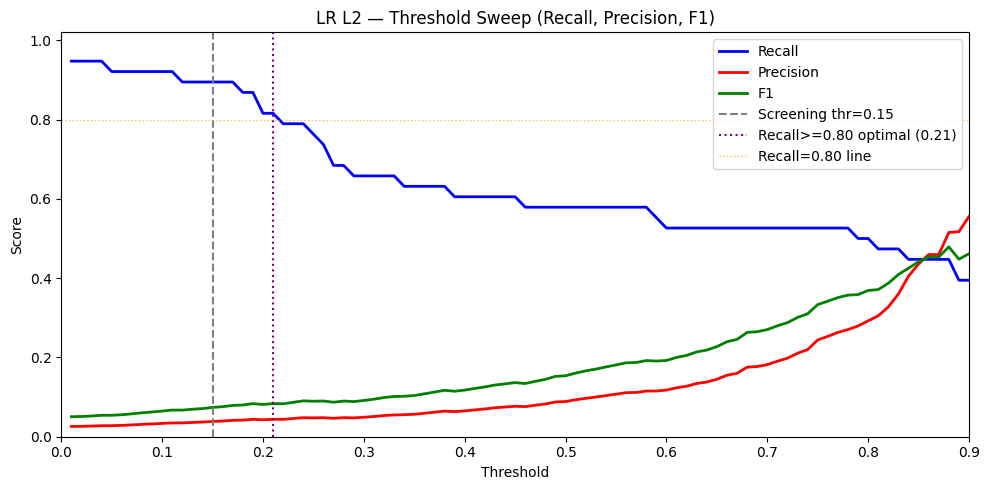

In [13]:
# Threshold sweep — find threshold for recall >= 0.80
thresholds = np.linspace(0.01, 0.90, 90)
probs_l2 = res_l2['prob']

recalls, precisions, f1s = [], [], []
for t in thresholds:
    pred = (probs_l2 >= t).astype(int)
    recalls.append(recall_score(y_te, pred, zero_division=0))
    precisions.append(precision_score(y_te, pred, zero_division=0))
    f1s.append(f1_score(y_te, pred, zero_division=0))

recall_arr = np.array(recalls)
f1_arr = np.array(f1s)
recall_mask = recall_arr >= 0.80
if recall_mask.any():
    best_thr_idx = np.argmax(f1_arr * recall_mask)
    best_thr_recall80 = thresholds[best_thr_idx]
    print(f'Optimal threshold for recall>=0.80: {best_thr_recall80:.3f}')
    print(f'  Recall={recalls[best_thr_idx]:.3f}, Precision={precisions[best_thr_idx]:.3f}, F1={f1s[best_thr_idx]:.3f}')
else:
    best_thr_recall80 = THR
    print('No threshold achieves recall>=0.80 — using THR=0.15')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recalls, 'b-', lw=2, label='Recall')
ax.plot(thresholds, precisions, 'r-', lw=2, label='Precision')
ax.plot(thresholds, f1s, 'g-', lw=2, label='F1')
ax.axvline(THR, color='gray', linestyle='--', lw=1.5, label=f'Screening thr={THR}')
ax.axvline(best_thr_recall80, color='purple', linestyle=':', lw=1.5,
           label=f'Recall>=0.80 optimal ({best_thr_recall80:.2f})')
ax.axhline(0.80, color='orange', linestyle=':', lw=1, alpha=0.7, label='Recall=0.80 line')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('LR L2 — Threshold Sweep (Recall, Precision, F1)')
ax.legend(); ax.set_xlim([0, 0.9]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## Section 6: Tree Models (RF & XGBoost)

RF           ROC-AUC=0.8083 Recall=0.3684 Prec=0.4828 F1=0.4179
XGBoost      ROC-AUC=0.8046 Recall=0.3684 Prec=0.3889 F1=0.3784


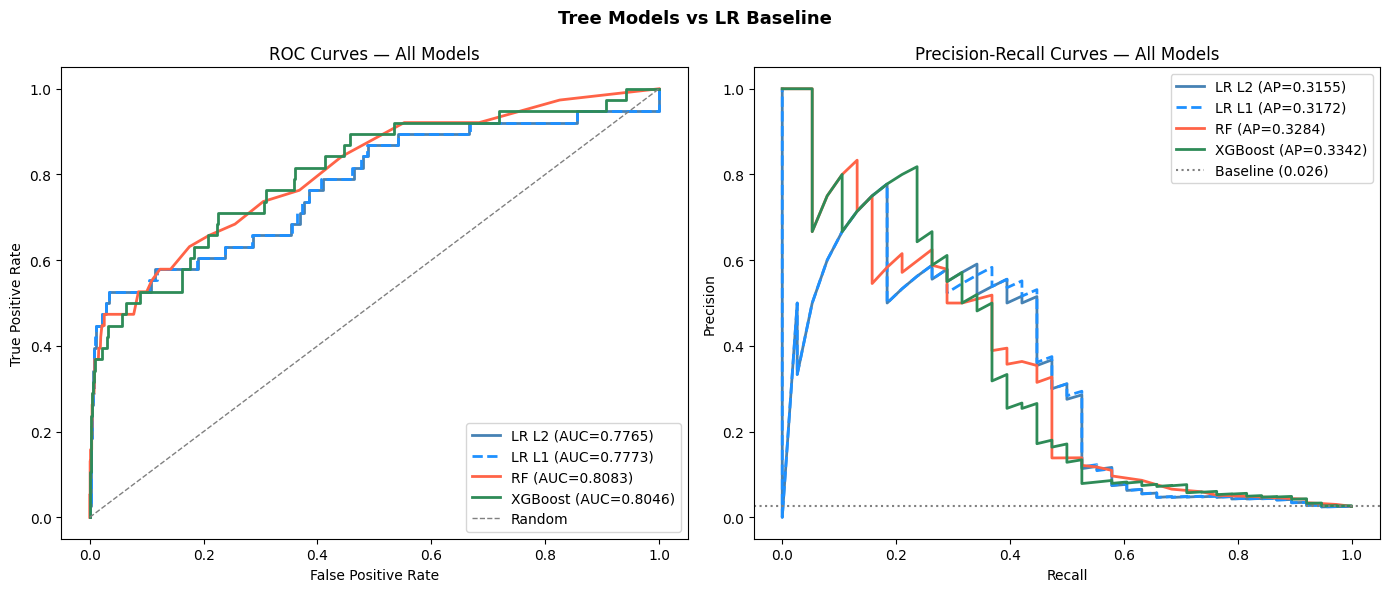

In [14]:
rf = make_rf()
rf.fit(X_tr, y_tr)

xgb_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(n_estimators=300, scale_pos_weight=SCALE_POS_WEIGHT,
                          random_state=SEED, eval_metric='logloss',
                          verbosity=0))
])
xgb_pipe.fit(X_tr, y_tr)

res_rf  = eval_model(rf, X_te, y_te, THR, 'RF')
res_xgb = eval_model(xgb_pipe, X_te, y_te, THR, 'XGBoost')
for r in [res_rf, res_xgb]:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} Recall={r['Recall']} Prec={r['Precision']} F1={r['F1']}")

# Comparison plots: ROC and PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for res, col, ls in [(res_l2,'steelblue','-'), (res_l1,'dodgerblue','--'),
                     (res_rf,'tomato','-'), (res_xgb,'seagreen','-')]:
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    ax.plot(fpr, tpr, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AUC={res['ROC-AUC']})")
ax.plot([0,1],[0,1],'--',color='gray',lw=1,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models'); ax.legend(loc='lower right')

ax = axes[1]
for res, col, ls in [(res_l2,'steelblue','-'), (res_l1,'dodgerblue','--'),
                     (res_rf,'tomato','-'), (res_xgb,'seagreen','-')]:
    prec, rec, _ = precision_recall_curve(y_te, res['prob'])
    ax.plot(rec, prec, lw=2, color=col, linestyle=ls,
            label=f"{res['name']} (AP={res['Avg Precision']})")
ax.axhline(y_te.mean(), color='gray', linestyle=':',lw=1.5,label=f'Baseline ({y_te.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models'); ax.legend()

plt.suptitle('Tree Models vs LR Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7: Feature Importances

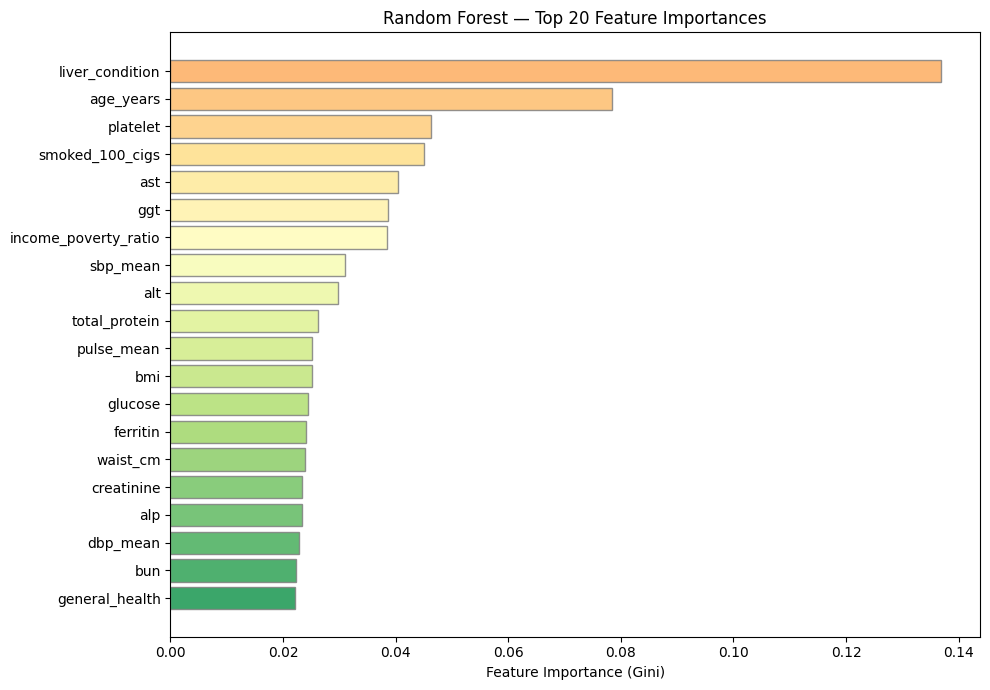

Top 10 RF features:
liver_condition         0.136931
age_years               0.078491
platelet                0.046259
smoked_100_cigs         0.045101
ast                     0.040430
ggt                     0.038621
income_poverty_ratio    0.038518
sbp_mean                0.031006
alt                     0.029839
total_protein           0.026175


In [15]:
# RF Feature importances (top 20)
rf_imp = rf.named_steps['clf'].feature_importances_
feat_names = X_all_full.columns.tolist()
rf_imp_series = pd.Series(rf_imp, index=feat_names).sort_values(ascending=False)
top20_rf = rf_imp_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))[::-1]
ax.barh(top20_rf.index[::-1], top20_rf.values[::-1], color=colors, edgecolor='gray', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()
print('Top 10 RF features:')
print(top20_rf.head(10).to_string())

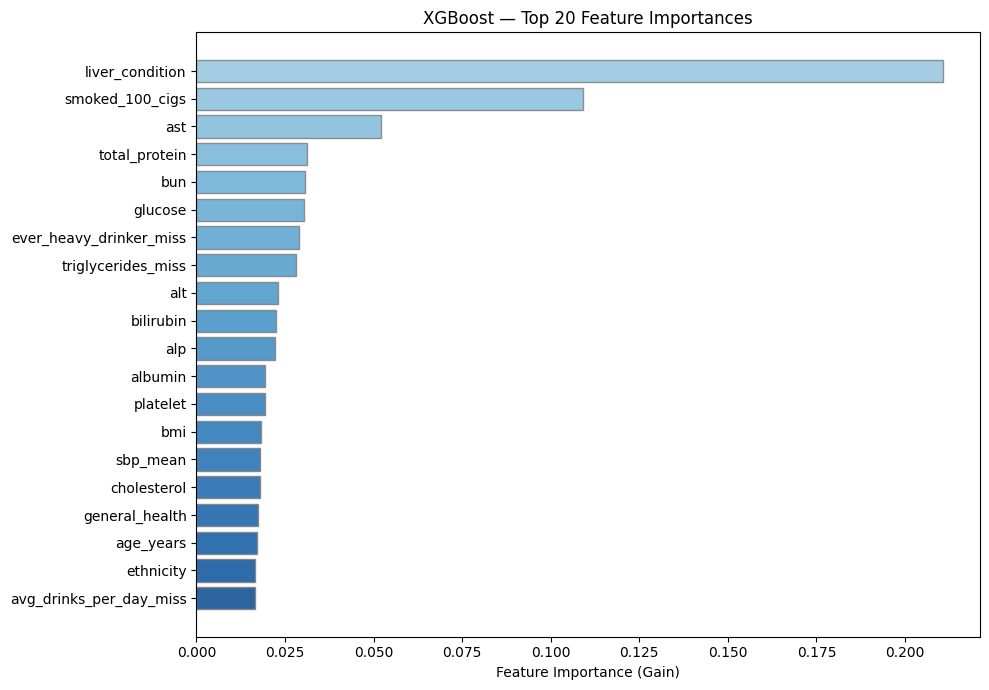

Top 10 XGBoost features:
liver_condition            0.210649
smoked_100_cigs            0.109253
ast                        0.052109
total_protein              0.031086
bun                        0.030660
glucose                    0.030223
ever_heavy_drinker_miss    0.029020
triglycerides_miss         0.028126
alt                        0.023080
bilirubin                  0.022539


In [16]:
# XGBoost feature importances (top 20)
xgb_model = xgb_pipe.named_steps['clf']
xgb_imp = xgb_model.feature_importances_
xgb_feat_names = X_all_full.columns.tolist()
xgb_imp_series = pd.Series(xgb_imp, index=xgb_feat_names).sort_values(ascending=False)
top20_xgb = xgb_imp_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_xgb = plt.cm.Blues(np.linspace(0.4, 0.9, 20))[::-1]
ax.barh(top20_xgb.index[::-1], top20_xgb.values[::-1], color=colors_xgb, edgecolor='gray', alpha=0.85)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Top 20 Feature Importances')
plt.tight_layout()
plt.show()
print('Top 10 XGBoost features:')
print(top20_xgb.head(10).to_string())

## Section 8: Calibration

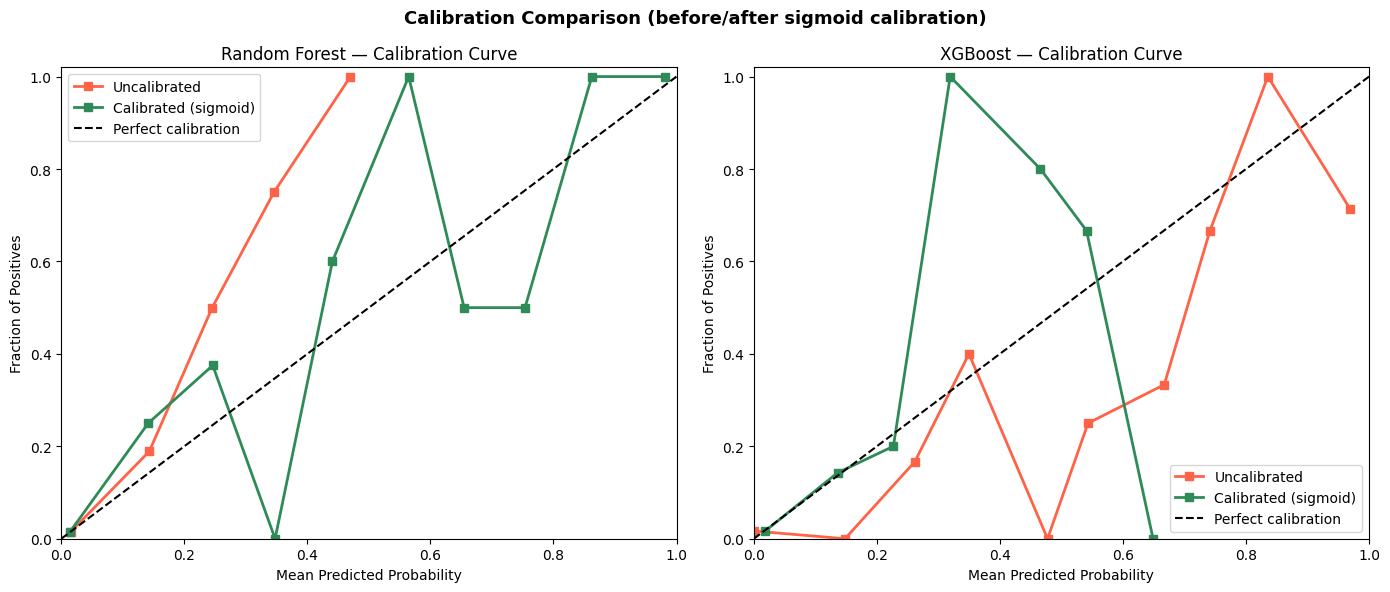

RF-Cal       ROC-AUC=0.8288 Recall=0.3947 Prec=0.4688
XGB-Cal      ROC-AUC=0.7827 Recall=0.3421 Prec=0.65


In [17]:
# Calibrate RF and XGBoost using 5-fold CV calibration (sklearn 1.8 compatible)
rf_cal_base = make_rf()
rf_calibrated = CalibratedClassifierCV(rf_cal_base, method='sigmoid', cv=5)
rf_calibrated.fit(X_tr, y_tr)

xgb_cal_base = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(n_estimators=300, scale_pos_weight=SCALE_POS_WEIGHT,
                          random_state=SEED, eval_metric='logloss', verbosity=0))
])
xgb_calibrated = CalibratedClassifierCV(xgb_cal_base, method='sigmoid', cv=5)
xgb_calibrated.fit(X_tr, y_tr)

prob_rf_raw  = rf.predict_proba(X_te)[:, 1]
prob_rf_cal  = rf_calibrated.predict_proba(X_te)[:, 1]
prob_xgb_raw = xgb_pipe.predict_proba(X_te)[:, 1]
prob_xgb_cal = xgb_calibrated.predict_proba(X_te)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, raw, cal, title in [
    (axes[0], prob_rf_raw, prob_rf_cal, 'Random Forest'),
    (axes[1], prob_xgb_raw, prob_xgb_cal, 'XGBoost')
]:
    frac_raw, mean_raw = calibration_curve(y_te, raw, n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_te, cal, n_bins=10)
    ax.plot(mean_raw, frac_raw, 's-', lw=2, color='tomato', label='Uncalibrated')
    ax.plot(mean_cal, frac_cal, 's-', lw=2, color='seagreen', label='Calibrated (sigmoid)')
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{title} — Calibration Curve')
    ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('Calibration Comparison (before/after sigmoid calibration)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

res_rf_cal  = eval_model(rf_calibrated,  X_te, y_te, THR, 'RF-Cal')
res_xgb_cal = eval_model(xgb_calibrated, X_te, y_te, THR, 'XGB-Cal')
for r in [res_rf_cal, res_xgb_cal]:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} Recall={r['Recall']} Prec={r['Precision']}")

## Section 9: Ensemble (Soft Vote: LR L1 + RF + XGBoost)

--- Ensemble: LR L1 + RF + XGBoost (soft vote) ---
SoftVote ROC-AUC=0.7823 AP=0.3731 Recall=0.6053 Prec=0.0712 F1=0.1274

--- All Models Comparison ---
LR L2        ROC-AUC=0.7765 AP=0.3155 Recall=0.8947 Prec=0.0385 F1=0.0738
LR L1        ROC-AUC=0.7773 AP=0.3172 Recall=0.8947 Prec=0.0382 F1=0.0733
RF           ROC-AUC=0.8083 AP=0.3284 Recall=0.3684 Prec=0.4828 F1=0.4179
XGBoost      ROC-AUC=0.8046 AP=0.3342 Recall=0.3684 Prec=0.3889 F1=0.3784
RF-Cal       ROC-AUC=0.8288 AP=0.335 Recall=0.3947 Prec=0.4688 F1=0.4286
XGB-Cal      ROC-AUC=0.7827 AP=0.3075 Recall=0.3421 Prec=0.65 F1=0.4483
SoftVote     ROC-AUC=0.7823 AP=0.3731 Recall=0.6053 Prec=0.0712 F1=0.1274


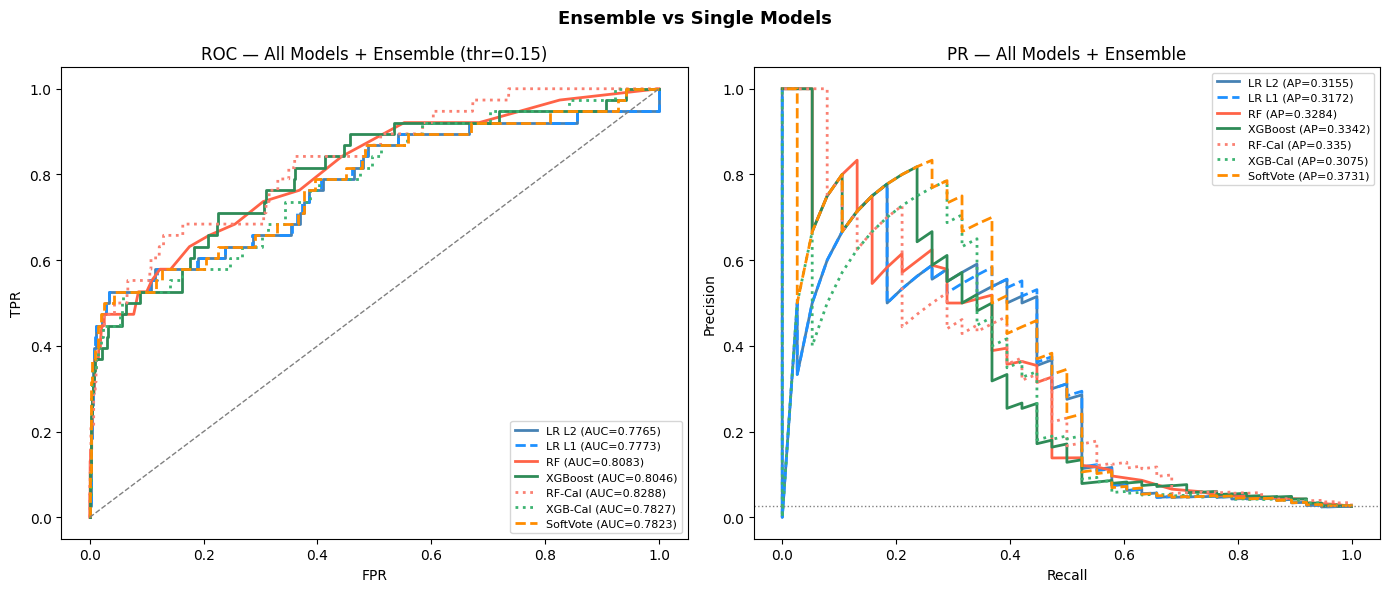

In [18]:
# Soft vote ensemble: LR L1 + RF + XGBoost
prob_softv = (res_l1['prob'] + res_rf['prob'] + res_xgb['prob']) / 3
pred_softv = (prob_softv >= THR).astype(int)

res_softv = {
    'name': 'SoftVote',
    'prob': prob_softv,
    'ROC-AUC':       round(roc_auc_score(y_te, prob_softv), 4),
    'Avg Precision': round(average_precision_score(y_te, prob_softv), 4),
    'Recall':        round(recall_score(y_te, pred_softv, zero_division=0), 4),
    'Precision':     round(precision_score(y_te, pred_softv, zero_division=0), 4),
    'Accuracy':      round(accuracy_score(y_te, pred_softv), 4),
    'F1':            round(f1_score(y_te, pred_softv, zero_division=0), 4),
}

all_results = [res_l2, res_l1, res_rf, res_xgb, res_rf_cal, res_xgb_cal, res_softv]

print(f'--- Ensemble: LR L1 + RF + XGBoost (soft vote) ---')
print(f"SoftVote ROC-AUC={res_softv['ROC-AUC']} AP={res_softv['Avg Precision']} "
      f"Recall={res_softv['Recall']} Prec={res_softv['Precision']} F1={res_softv['F1']}")

print('\n--- All Models Comparison ---')
for r in all_results:
    print(f"{r['name']:12} ROC-AUC={r['ROC-AUC']} AP={r['Avg Precision']} "
          f"Recall={r['Recall']} Prec={r['Precision']} F1={r['F1']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_ens = ['steelblue', 'dodgerblue', 'tomato', 'seagreen', 'salmon', 'mediumseagreen', 'darkorange']
ls_ens = ['-', '--', '-', '-', ':', ':', '--']

ax = axes[0]
for res, col, ls in zip(all_results, colors_ens, ls_ens):
    fpr, tpr, _ = roc_curve(y_te, res['prob'])
    ax.plot(fpr, tpr, lw=2, color=col, linestyle=ls, label=f"{res['name']} (AUC={res['ROC-AUC']})")
ax.plot([0,1],[0,1],'--',color='gray',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC — All Models + Ensemble (thr={THR})')
ax.legend(loc='lower right', fontsize=8)

ax = axes[1]
for res, col, ls in zip(all_results, colors_ens, ls_ens):
    prec, rec, _ = precision_recall_curve(y_te, res['prob'])
    ax.plot(rec, prec, lw=2, color=col, linestyle=ls,
            label=f"{res['name']} (AP={res['Avg Precision']})")
ax.axhline(y_te.mean(), color='gray', linestyle=':',lw=1)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR — All Models + Ensemble'); ax.legend(fontsize=8)

plt.suptitle('Ensemble vs Single Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 10: Bootstrap Feature Stability (LR, QUEST features)

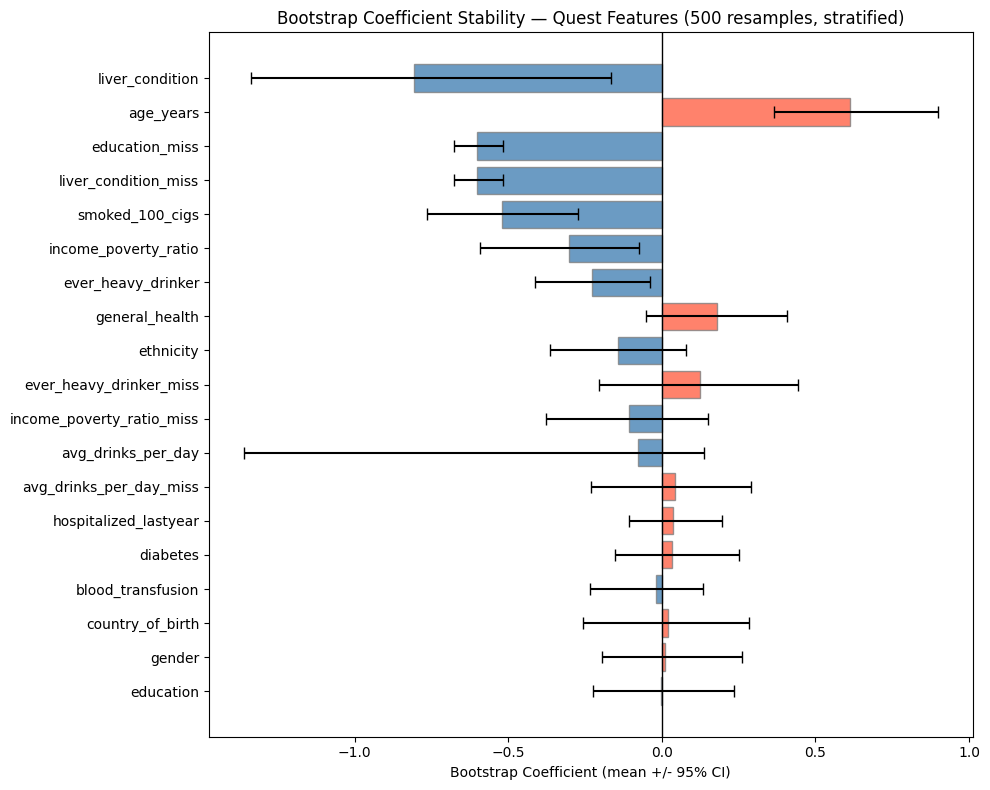

Stable positive features (1): ['age_years']
Stable negative features (6): ['income_poverty_ratio', 'ever_heavy_drinker', 'smoked_100_cigs', 'liver_condition', 'education_miss', 'liver_condition_miss']


In [19]:
# Bootstrap coefficient stability (500 resamples) — QUEST_FEATURES only
# Use StratifiedKFold-aware resampling to ensure positives in each resample
X_quest_tr = X_quest_full.iloc[tr_idx]
y_quest_tr = y_tr

quest_cols = X_quest_full.columns.tolist()
n_boot = 500
boot_coefs = np.zeros((n_boot, len(quest_cols)))

lr_boot = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                               max_iter=2000, random_state=SEED, solver='lbfgs')
imp_boot = SimpleImputer(strategy='median')
sc_boot  = StandardScaler()

X_quest_tr_imp = sc_boot.fit_transform(imp_boot.fit_transform(X_quest_tr))

for i in range(n_boot):
    X_b, y_b = resample(X_quest_tr_imp, y_quest_tr.values,
                        random_state=i, stratify=y_quest_tr.values)
    try:
        lr_boot.fit(X_b, y_b)
        boot_coefs[i] = lr_boot.coef_[0]
    except Exception:
        boot_coefs[i] = 0

coef_mean  = np.mean(boot_coefs, axis=0)
coef_std   = np.std(boot_coefs, axis=0)
coef_ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
coef_ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

order   = np.argsort(np.abs(coef_mean))[::-1]
top_n   = min(20, len(quest_cols))
top_idx = order[:top_n]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(top_n)
means_plot = coef_mean[top_idx]
lo_err = means_plot - coef_ci_lo[top_idx]
hi_err = coef_ci_hi[top_idx] - means_plot
colors_boot = ['tomato' if m > 0 else 'steelblue' for m in means_plot]
ax.barh(y_pos, means_plot[::-1], xerr=[lo_err[::-1], hi_err[::-1]],
        color=colors_boot[::-1], edgecolor='gray', alpha=0.8, capsize=4)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([quest_cols[i] for i in top_idx[::-1]])
ax.set_xlabel('Bootstrap Coefficient (mean +/- 95% CI)')
ax.set_title('Bootstrap Coefficient Stability — Quest Features (500 resamples, stratified)')
plt.tight_layout()
plt.show()

stable_positive = [(quest_cols[i], coef_mean[i]) for i in range(len(quest_cols)) if coef_ci_lo[i] > 0]
stable_negative = [(quest_cols[i], coef_mean[i]) for i in range(len(quest_cols)) if coef_ci_hi[i] < 0]
print(f'Stable positive features ({len(stable_positive)}):', [x[0] for x in stable_positive])
print(f'Stable negative features ({len(stable_negative)}):', [x[0] for x in stable_negative])

## Section 11: L1 Regularisation Path

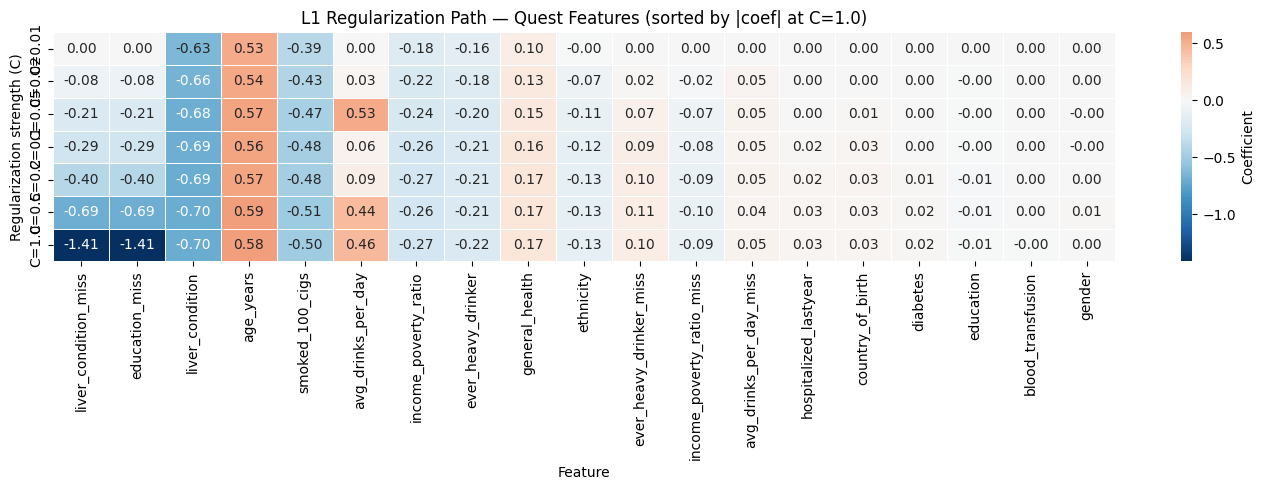

In [20]:
# L1 regularization path heatmap
C_values = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

coef_path = np.zeros((len(C_values), len(quest_cols)))
for j, C in enumerate(C_values):
    lr_path = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(penalty='elasticnet', C=C, l1_ratio=1.0,
                                    class_weight='balanced', max_iter=3000,
                                    random_state=SEED, solver='saga'))
    ])
    lr_path.fit(X_quest_tr, y_quest_tr)
    coef_path[j] = lr_path.named_steps['clf'].coef_[0]

coef_path_df = pd.DataFrame(coef_path, index=[f'C={c}' for c in C_values], columns=quest_cols)
sort_order = coef_path_df.loc['C=1.0'].abs().sort_values(ascending=False).index
coef_path_df_sorted = coef_path_df[sort_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(coef_path_df_sorted, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coefficient'})
ax.set_title('L1 Regularization Path — Quest Features (sorted by |coef| at C=1.0)')
ax.set_xlabel('Feature'); ax.set_ylabel('Regularization strength (C)')
plt.tight_layout()
plt.show()

## Section 12: Feature Tier Classification

In [21]:
# Tier classification: STRONG / BORDERLINE / REMOVE
tiers = {}
for i, col in enumerate(quest_cols):
    mean_c = coef_mean[i]
    lo_c   = coef_ci_lo[i]
    hi_c   = coef_ci_hi[i]
    ci_crosses_zero = (lo_c <= 0 <= hi_c)
    abs_mean = abs(mean_c)
    survives_l1 = (col in coef_path_df.columns) and (abs(coef_path_df.loc['C=0.2', col]) > 0.01)

    if not ci_crosses_zero and survives_l1:
        tiers[col] = 'STRONG'
    elif abs_mean > 0.05:
        tiers[col] = 'BORDERLINE'
    else:
        tiers[col] = 'REMOVE'

tier_df = pd.DataFrame([
    {'feature': col, 'tier': tier, 'mean_coef': round(coef_mean[i], 4),
     'ci_lo': round(coef_ci_lo[i], 4), 'ci_hi': round(coef_ci_hi[i], 4)}
    for i, (col, tier) in enumerate(tiers.items())
]).sort_values(['tier', 'mean_coef'], ascending=[True, False]).reset_index(drop=True)

print('Feature Tier Classification:')
print(tier_df.to_string(index=False))
print(f"\nSTRONG: {(tier_df.tier=='STRONG').sum()}")
print(f"BORDERLINE: {(tier_df.tier=='BORDERLINE').sum()}")
print(f"REMOVE: {(tier_df.tier=='REMOVE').sum()}")

STRONG_QUEST     = tier_df.loc[tier_df.tier=='STRONG',     'feature'].tolist()
BORDERLINE_QUEST = tier_df.loc[tier_df.tier=='BORDERLINE', 'feature'].tolist()
STRONG_QUEST_BASE     = [f for f in STRONG_QUEST     if f in QUEST_FEATURES]
BORDERLINE_QUEST_BASE = [f for f in BORDERLINE_QUEST if f in QUEST_FEATURES]
print('\nSTRONG base features:', STRONG_QUEST_BASE)
print('BORDERLINE base features:', BORDERLINE_QUEST_BASE)

Feature Tier Classification:
                  feature       tier  mean_coef   ci_lo   ci_hi
           general_health BORDERLINE     0.1802 -0.0530  0.4081
  ever_heavy_drinker_miss BORDERLINE     0.1237 -0.2048  0.4445
       avg_drinks_per_day BORDERLINE    -0.0793 -1.3614  0.1361
income_poverty_ratio_miss BORDERLINE    -0.1073 -0.3757  0.1495
                ethnicity BORDERLINE    -0.1436 -0.3637  0.0775
  avg_drinks_per_day_miss     REMOVE     0.0412 -0.2300  0.2916
    hospitalized_lastyear     REMOVE     0.0362 -0.1074  0.1964
                 diabetes     REMOVE     0.0332 -0.1539  0.2512
         country_of_birth     REMOVE     0.0190 -0.2570  0.2841
                   gender     REMOVE     0.0110 -0.1937  0.2620
                education     REMOVE    -0.0036 -0.2245  0.2347
        blood_transfusion     REMOVE    -0.0191 -0.2324  0.1332
                age_years     STRONG     0.6134  0.3654  0.8986
       ever_heavy_drinker     STRONG    -0.2284 -0.4118 -0.0373
     income

## Section 13: Cross-validate 3 Feature Sets


Feature Selection CV Results (5-fold LR L2):
All (LAB+QUEST)           n= 36 ROC-AUC=0.8099+/-0.0103  AP=0.2187+/-0.0585
STRONG only               n=  5 ROC-AUC=0.8211+/-0.0210  AP=0.2479+/-0.0832
STRONG+LAB                n= 27 ROC-AUC=0.8117+/-0.0152  AP=0.2334+/-0.0576


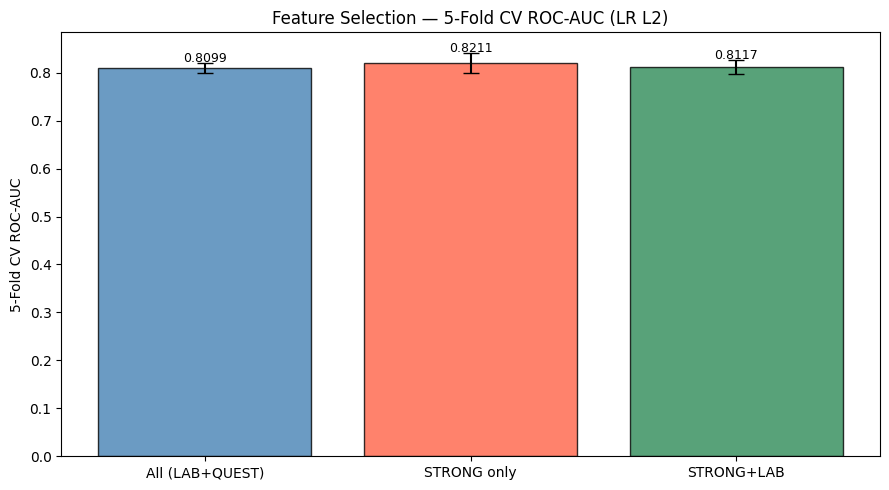

In [22]:
# Cross-validate 3 feature sets: all, STRONG only, STRONG+LAB
feat_sets = {
    'All (LAB+QUEST)':   ALL_FEATURES,
    'STRONG only':       STRONG_QUEST_BASE if STRONG_QUEST_BASE else QUEST_FEATURES[:5],
    'STRONG+LAB':        list(dict.fromkeys(STRONG_QUEST_BASE + LAB_FEATURES))
                         if STRONG_QUEST_BASE else ALL_FEATURES,
}

cv5_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fs_results = {}
for name, feats in feat_sets.items():
    if not feats:
        feats = ALL_FEATURES
    X_fs = add_missing_flags(df[feats])
    cv_res = cross_validate(
        make_lr_l2(), X_fs, y_full, cv=cv5_fs,
        scoring={'roc_auc': 'roc_auc', 'average_precision': 'average_precision'}
    )
    fs_results[name] = {
        'n_feats':       len(feats),
        'roc_auc_mean':  cv_res['test_roc_auc'].mean(),
        'roc_auc_std':   cv_res['test_roc_auc'].std(),
        'ap_mean':       cv_res['test_average_precision'].mean(),
        'ap_std':        cv_res['test_average_precision'].std(),
    }

print('\nFeature Selection CV Results (5-fold LR L2):')
for name, r in fs_results.items():
    print(f"{name:25} n={r['n_feats']:3d} ROC-AUC={r['roc_auc_mean']:.4f}+/-{r['roc_auc_std']:.4f}  AP={r['ap_mean']:.4f}+/-{r['ap_std']:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
names  = list(fs_results.keys())
means  = [fs_results[n]['roc_auc_mean'] for n in names]
stds   = [fs_results[n]['roc_auc_std']  for n in names]
ax.bar(names, means, yerr=stds, capsize=6,
       color=['steelblue','tomato','seagreen'], edgecolor='black', alpha=0.8)
ax.set_ylabel('5-Fold CV ROC-AUC')
ax.set_title('Feature Selection — 5-Fold CV ROC-AUC (LR L2)')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.002, f'{m:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Section 14: Master Comparison Table

In [23]:
# Build master comparison DataFrame
all_res = [res_l2, res_l1, res_rf, res_xgb, res_rf_cal, res_xgb_cal, res_softv]

comparison_rows = []
for r in all_res:
    comparison_rows.append({
        'Model':         r['name'],
        'ROC-AUC':       r['ROC-AUC'],
        'Avg Precision': r['Avg Precision'],
        'Recall':        r['Recall'],
        'Precision':     r['Precision'],
        'F1':            r['F1'],
        'Accuracy':      r['Accuracy'],
        'Threshold':     THR,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(f'=== Master Comparison Table (thr={THR}) ===')
print(comparison_df.to_string(index=False))

# Optimal threshold table
print('\n=== Optimal Threshold Table (maximizes F1) ===')
opt_rows = []
thresholds_sweep = np.linspace(0.01, 0.99, 99)
for r in all_res:
    best_f1, best_thr, best_rec, best_prec = 0, 0.5, 0, 0
    for t in thresholds_sweep:
        pred = (r['prob'] >= t).astype(int)
        f1_t = f1_score(y_te, pred, zero_division=0)
        if f1_t > best_f1:
            best_f1   = f1_t
            best_thr  = t
            best_rec  = recall_score(y_te, pred, zero_division=0)
            best_prec = precision_score(y_te, pred, zero_division=0)
    opt_rows.append({
        'Model': r['name'], 'Opt Threshold': round(best_thr, 3),
        'Best F1': round(best_f1, 4), 'Recall': round(best_rec, 4), 'Precision': round(best_prec, 4)
    })

opt_df = pd.DataFrame(opt_rows)
print(opt_df.to_string(index=False))

=== Master Comparison Table (thr=0.15) ===
   Model  ROC-AUC  Avg Precision  Recall  Precision     F1  Accuracy  Threshold
  RF-Cal   0.8288         0.3350  0.3947     0.4688 0.4286    0.9731       0.15
      RF   0.8083         0.3284  0.3684     0.4828 0.4179    0.9738       0.15
 XGBoost   0.8046         0.3342  0.3684     0.3889 0.3784    0.9691       0.15
 XGB-Cal   0.7827         0.3075  0.3421     0.6500 0.4483    0.9785       0.15
SoftVote   0.7823         0.3731  0.6053     0.0712 0.1274    0.7883       0.15
   LR L1   0.7773         0.3172  0.8947     0.0382 0.0733    0.4220       0.15
   LR L2   0.7765         0.3155  0.8947     0.0385 0.0738    0.4267       0.15

=== Optimal Threshold Table (maximizes F1) ===


   Model  Opt Threshold  Best F1  Recall  Precision
   LR L2           0.88   0.4789  0.4474     0.5152
   LR L1           0.88   0.4857  0.4474     0.5312
      RF           0.16   0.4308  0.3684     0.5185
 XGBoost           0.26   0.4242  0.3684     0.5000
  RF-Cal           0.15   0.4286  0.3947     0.4688
 XGB-Cal           0.15   0.4483  0.3421     0.6500
SoftVote           0.48   0.4828  0.3684     0.7000


## Section 15: Final Model Export

Best ROC-AUC model is noted. We save **LR L1** as the final exported model — same rationale as the inflammation notebook: interpretable, lean, deployable without ensemble infrastructure.

With only 192 events (rule of thumb: max ~15–19 predictors), L1 regularisation helps keep the model lean by zeroing out less informative features.

In [24]:
# Best model by test ROC-AUC
best_row        = comparison_df.iloc[0]
best_model_name = best_row['Model']
best_roc        = best_row['ROC-AUC']
print(f'Best model by test ROC-AUC: {best_model_name} (AUC={best_roc})')

# LR L1 details from test set
lr_l1_coefs_test   = lr_l1.named_steps['clf'].coef_[0]
feat_names_all     = X_all_full.columns.tolist()
nonzero_mask       = lr_l1_coefs_test != 0
nonzero_feat_names = [f for f, nz in zip(feat_names_all, nonzero_mask) if nz]
nonzero_coefs      = lr_l1_coefs_test[nonzero_mask]
print(f'\nLR L1 nonzero features: {nonzero_mask.sum()} / {len(feat_names_all)}')
print('\nTop 10 LR L1 coefficients by absolute value:')
coef_series = pd.Series(lr_l1_coefs_test, index=feat_names_all)
top10_coef  = coef_series.abs().sort_values(ascending=False).head(10)
for feat in top10_coef.index:
    print(f'  {feat:45s} : {coef_series[feat]:+.4f}')

# Retrain LR L1 on FULL dataset for export
# Count nonzero features from FULL-data model
final_model = make_lr_l1(C=1.0)
final_model.fit(X_all_full, y_full)

lr_coefs_full   = final_model.named_steps['clf'].coef_[0]
nonzero_full    = (lr_coefs_full != 0)
nonzero_n       = nonzero_full.sum()
nonzero_feats   = [f for f, nz in zip(feat_names_all, nonzero_full) if nz]
coef_dict_full  = {feat: round(float(c), 6) for feat, c in zip(feat_names_all, lr_coefs_full)}
nonzero_dict    = {feat: round(float(c), 6) for feat, c in zip(feat_names_all, lr_coefs_full) if c != 0}

model_filename = f'hepatitis_lr_l1_{nonzero_n}feat'
print(f'\nFull-data LR L1 nonzero features: {nonzero_n}')
print(f'Model filename: {model_filename}')

# Save model
models_dir  = '../models'
os.makedirs(models_dir, exist_ok=True)
joblib_path = os.path.join(models_dir, f'{model_filename}.joblib')
joblib.dump(final_model, joblib_path)
print(f'Model saved: {joblib_path}')

# Save metadata
metadata = {
    'model_name':          model_filename,
    'model_type':          'LogisticRegression_L1_ElasticNet_l1ratio1_saga',
    'best_test_model':     best_model_name,
    'best_test_roc_auc':   float(best_roc),
    'model_version':       '1.0.0',
    'created_at':          datetime.now().isoformat(),
    'description':         (
        f'LR L1 hepatitis B/C screening model trained on all {len(ALL_FEATURES)} base features '
        f'(LAB+QUEST) with missingness flags. Severely imbalanced target (2.6% positive). '
        f'class_weight=balanced, scale_pos_weight={SCALE_POS_WEIGHT:.2f}. '
        f'Best test model: {best_model_name} (ROC-AUC={best_roc}). '
        f'Saved model: LR L1 for interpretability and lean feature set.'
    ),
    'rationale':           (
        'LR L1 selected over best-AUC model for deployment: interpretable, lean (automatic feature '
        'selection via L1 sparsity), deployable without ensemble infrastructure. '
        'With only 192 events (rule-of-thumb: max 15-19 predictors), L1 regularization helps '
        'prevent overfitting by zeroing out less informative features.'
    ),
    'target':              TARGET,
    'screening_threshold': THR,
    'class_imbalance': {
        'n_positive':     int(n_pos),
        'n_negative':     int(n_neg),
        'prevalence_pct': round(float(n_pos / (n_pos + n_neg) * 100), 2),
        'scale_pos_weight': round(float(SCALE_POS_WEIGHT), 2),
    },
    'n_train_total':       int(len(df)),
    'n_train_used':        int(len(tr_idx)),
    'n_test':              int(len(te_idx)),
    'seed':                SEED,
    'lab_base_features':   LAB_FEATURES,
    'quest_base_features': QUEST_FEATURES,
    'all_base_features':   ALL_FEATURES,
    'n_base_features':     len(ALL_FEATURES),
    'n_features_total':    int(X_all_full.shape[1]),
    'miss_flag_features':  [c for c in feat_names_all if c.endswith('_miss')],
    'field_names':         feat_names_all,
    'nonzero_features':    nonzero_feats,
    'n_nonzero_features':  int(nonzero_n),
    'coefficients':        coef_dict_full,
    'nonzero_coefficients': nonzero_dict,
    'test_metrics': {
        r['name']: {k: v for k, v in r.items() if k not in ['prob', 'name']}
        for r in all_res
    },
    'imputer_strategy':    'median',
    'scaler':              'StandardScaler',
    'class_weight':        'balanced',
    'solver':              'saga',
    'penalty':             'elasticnet',
    'l1_ratio':            1.0,
    'max_iter':            3000,
}

metadata_path = os.path.join(models_dir, f'{model_filename}_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f'Metadata saved: {metadata_path}')

print(f'\n=== FINAL SUMMARY ===')
print(f'Best model by test ROC-AUC: {best_model_name} (AUC={best_roc})')
print(f'Saved model: LR L1 — {nonzero_n} nonzero features (full-data retrain)')
print(f'LR L1 test ROC-AUC:            {res_l1["ROC-AUC"]}')
print(f'LR L1 test Recall@thr={THR}:   {res_l1["Recall"]}')
print(f'LR L1 test Precision@thr={THR}:{res_l1["Precision"]}')
print(f'Saved to: {joblib_path}')
print(f'Metadata: {metadata_path}')

Best model by test ROC-AUC: RF-Cal (AUC=0.8288)

LR L1 nonzero features: 57 / 63

Top 10 LR L1 coefficients by absolute value:
  liver_condition_miss                          : -0.9968
  education_miss                                : -0.9968
  liver_condition                               : -0.6480
  smoked_100_cigs                               : -0.6300
  age_years                                     : +0.5955
  bmi                                           : -0.4875
  albumin                                       : -0.4656
  alt                                           : +0.4390
  cholesterol_miss                              : +0.3837
  hdl_miss                                      : +0.3837



Full-data LR L1 nonzero features: 60
Model filename: hepatitis_lr_l1_60feat
Model saved: ../models/hepatitis_lr_l1_60feat.joblib
Metadata saved: ../models/hepatitis_lr_l1_60feat_metadata.json

=== FINAL SUMMARY ===
Best model by test ROC-AUC: RF-Cal (AUC=0.8288)
Saved model: LR L1 — 60 nonzero features (full-data retrain)
LR L1 test ROC-AUC:            0.7773
LR L1 test Recall@thr=0.15:   0.8947
LR L1 test Precision@thr=0.15:0.0382
Saved to: ../models/hepatitis_lr_l1_60feat.joblib
Metadata: ../models/hepatitis_lr_l1_60feat_metadata.json
